In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! pip install linearmodels
import linearmodels
from linearmodels.iv import IV2SLS
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


sec_data = pd.read_csv("/content/drive/MyDrive/Empirical Methods for Finance Assignment/Assignment 2/sec_reviewer_data.csv")

selected_columns = [
    "number_issues", "sec_reviewer", "cik",
    "amendment", "number_amendments", "investigation",
    "LATEST_FLOAT", "IS_ACCEL_FILER", "IS_IN_SP500",
    "IS_IN_RUSSELL_2000", "IS_IN_NASDAQ_COMPOSITE",
    "sic", "year", "sec_industry_office"
]
df = sec_data[selected_columns].copy()


df = df.dropna()


g = df.groupby("sec_reviewer")["number_issues"].agg(["sum", "count"])
g = g[g["count"] > 1]
df = df.merge(g, left_on="sec_reviewer", right_index=True, suffixes=("", "_reviewer"))
df["instrument_strictness_loo"] = (df["sum"] - df["number_issues"]) / (df["count"] - 1)
df = df.drop(columns=["sum", "count"])


/tmp/ipython-input-1589207056.py:10: DtypeWarning: Columns (42,43,44,46,57,58,59,64,67) have mixed types. Specify dtype option on import or set low_memory=False.
  sec_data = pd.read_csv("/content/drive/MyDrive/Empirical Methods for Finance Assignment/Assignment 2/sec_reviewer_data.csv")


In [ ]:
df["log_float"] = np.log1p(df["LATEST_FLOAT"])


controls = [
    "log_float",
    "IS_ACCEL_FILER",
    "IS_IN_SP500",
    "IS_IN_RUSSELL_2000",
    "IS_IN_NASDAQ_COMPOSITE"
]

X = df[controls]
X = sm.add_constant(X)
endog = df["number_issues"]
instrument = df["instrument_strictness_loo"]

In [ ]:
def run_iv(depvar):
    y = df[depvar]
    model = IV2SLS(
        dependent=y,
        exog=X,
        endog=endog,
        instruments=instrument
    ).fit(cov_type="robust")


    print("\nIV Results for:", depvar, "\n")


    print(model.summary)
    print("\n--- First Stage Diagnostics ---")
    print(model.first_stage)
    print("\n" + "="*50 + "\n")



run_iv("amendment")
run_iv("number_amendments")
run_iv("investigation")


IV Results for: amendment 

                          IV-2SLS Estimation Summary                          
Dep. Variable:              amendment   R-squared:                      0.0044
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0043
No. Observations:               62988   F-statistic:                    1122.6
Date:                Mon, Nov 24 2025   P-value (F-stat)                0.0000
Time:                        11:40:25   Distribution:                  chi2(6)
Cov. Estimator:                robust                                         
                                                                              
                                   Parameter Estimates                                    
                        Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------------
const                      0.2639     0.0148     17.818     0.0000

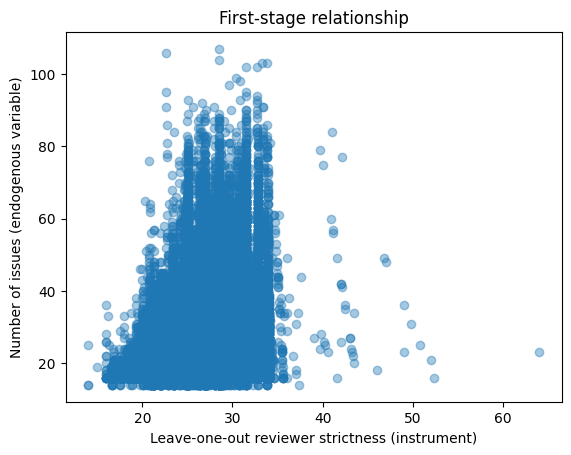

In [ ]:
plt.scatter(df["instrument_strictness_loo"], df["number_issues"], alpha=0.4)
plt.xlabel("Leave-one-out reviewer strictness (instrument)")
plt.ylabel("Number of issues (endogenous variable)")
plt.title("First-stage relationship")
plt.show()
